# Bank Customer Churn Prediction

This notebook explores customer churn and builds classification models to identify customers
who may leave the bank. The work follows a practical machine-learning workflow: understand
the data, create meaningful features, train several models, and compare their performance.


## 1. Import Libraries

The libraries below cover data manipulation, visualization, preprocessing, model training,
tuning, and evaluation. A fixed random seed is used throughout so that results are
reproducible when the notebook is run again.


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
TEST_SIZE = 0.20

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 100)


## 2. Load Dataset

The churn dataset is loaded from the project folder. Keeping the file path in one variable
makes the notebook easier to reuse and avoids hard-coded paths from a different environment.


In [2]:
data_path = Path("Churn_Modelling.csv")

if not data_path.exists():
    raise FileNotFoundError(f"Dataset not found: {data_path.resolve()}")

customer_df = pd.read_csv(data_path)
customer_df.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 3. Data Understanding

Before changing the data, we inspect its size, schema, completeness, and summary statistics.
This confirms the prediction target and highlights data-quality issues that could affect the
analysis or model performance.


In [3]:
print(f"Dataset shape: {customer_df.shape}")
print(f"\nColumns:\n{customer_df.columns.tolist()}")

display(customer_df.info())
display(customer_df.describe(include="all").T)


Dataset shape: (10000, 14)

Columns:
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 n

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
CustomerId,10000.0,NaN,NaN,NaN,15690940.5694,71936.186123,15565701.0,15628528.25,15690738.0,15753233.75,15815690.0
Surname,10000,2932,Smith,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
Geography,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
Tenure,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
Balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
NumOfProducts,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0


In [4]:
data_summary = pd.DataFrame({
    "data_type": customer_df.dtypes.astype(str),
    "missing_values": customer_df.isna().sum(),
    "unique_values": customer_df.nunique(),
})

display(data_summary)


,data_type,missing_values,unique_values
RowNumber,int64,0,10000
CustomerId,int64,0,10000
Surname,object,0,2932
CreditScore,int64,0,460
Geography,object,0,3
Gender,object,0,2
Age,int64,0,70
Tenure,int64,0,11
Balance,float64,0,6382
NumOfProducts,int64,0,4


The dataset contains customer demographics, account details, and the `Exited` target. The
identifier-like columns should not be used as predictive features because they do not describe
customer behaviour and can create misleading patterns.


## 4. Data Cleaning

This step checks for missing and duplicate records, then removes columns that identify a
customer rather than describe their relationship with the bank. The source dataset is kept
unchanged; a cleaned copy is used for the rest of the notebook.


In [5]:
target_column = "Exited"
identifier_columns = ["RowNumber", "CustomerId", "Surname"]

print("Missing values by column:")
display(customer_df.isna().sum().sort_values(ascending=False))
print(f"\nDuplicate rows: {customer_df.duplicated().sum()}")

cleaned_df = customer_df.drop_duplicates().copy()
cleaned_df = cleaned_df.drop(columns=identifier_columns)

print(f"Shape after cleaning: {cleaned_df.shape}")


Missing values by column:


RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


Duplicate rows: 0
Shape after cleaning: (10000, 11)


No imputation is required when the source file has no missing values. The preprocessing
pipeline later still includes imputers so the model remains robust if a future scoring file
contains incomplete values.


## 5. Exploratory Data Analysis (EDA)

EDA identifies the patterns that are most relevant to churn. The focus is on class balance,
distributions, customer segments, and how each feature relates to the target.


Overall churn rate: 20.4%


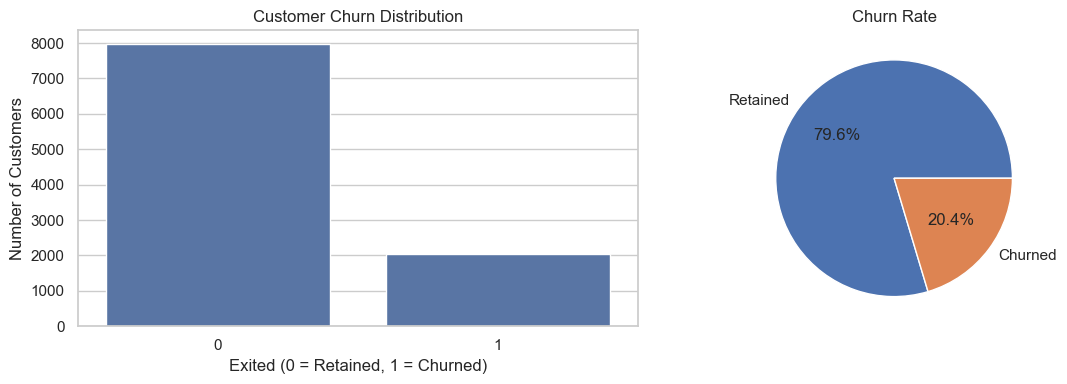

In [6]:
churn_rate = cleaned_df[target_column].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=cleaned_df, x=target_column, ax=axes[0])
axes[0].set_title("Customer Churn Distribution")
axes[0].set_xlabel("Exited (0 = Retained, 1 = Churned)")
axes[0].set_ylabel("Number of Customers")

cleaned_df[target_column].value_counts().sort_index().plot(
    kind="pie",
    autopct="%.1f%%",
    labels=["Retained", "Churned"],
    ylabel="",
    ax=axes[1],
)
axes[1].set_title("Churn Rate")
plt.tight_layout()

print(f"Overall churn rate: {churn_rate:.1%}")


The target distribution shows that churn is the minority class. Accuracy is still useful for
comparison, but precision, recall, F1 score, and ROC-AUC are also needed to understand how
effectively a model identifies customers who actually churn.


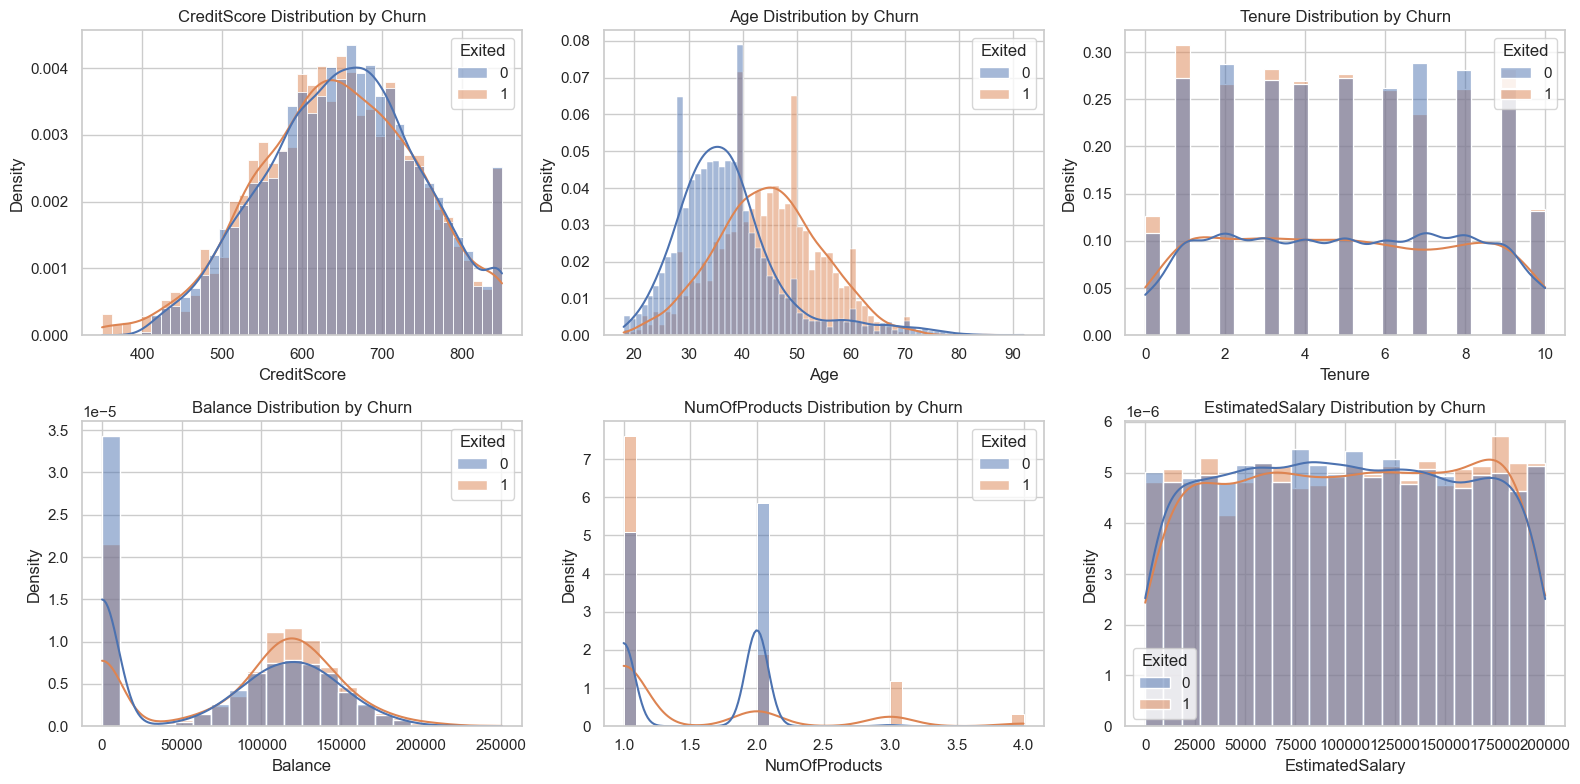

In [7]:
numeric_features = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary",
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for axis, feature in zip(axes.ravel(), numeric_features):
    sns.histplot(
        data=cleaned_df,
        x=feature,
        hue=target_column,
        kde=True,
        stat="density",
        common_norm=False,
        ax=axis,
    )
    axis.set_title(f"{feature} Distribution by Churn")
    axis.set_xlabel(feature)
    axis.set_ylabel("Density")
plt.tight_layout()


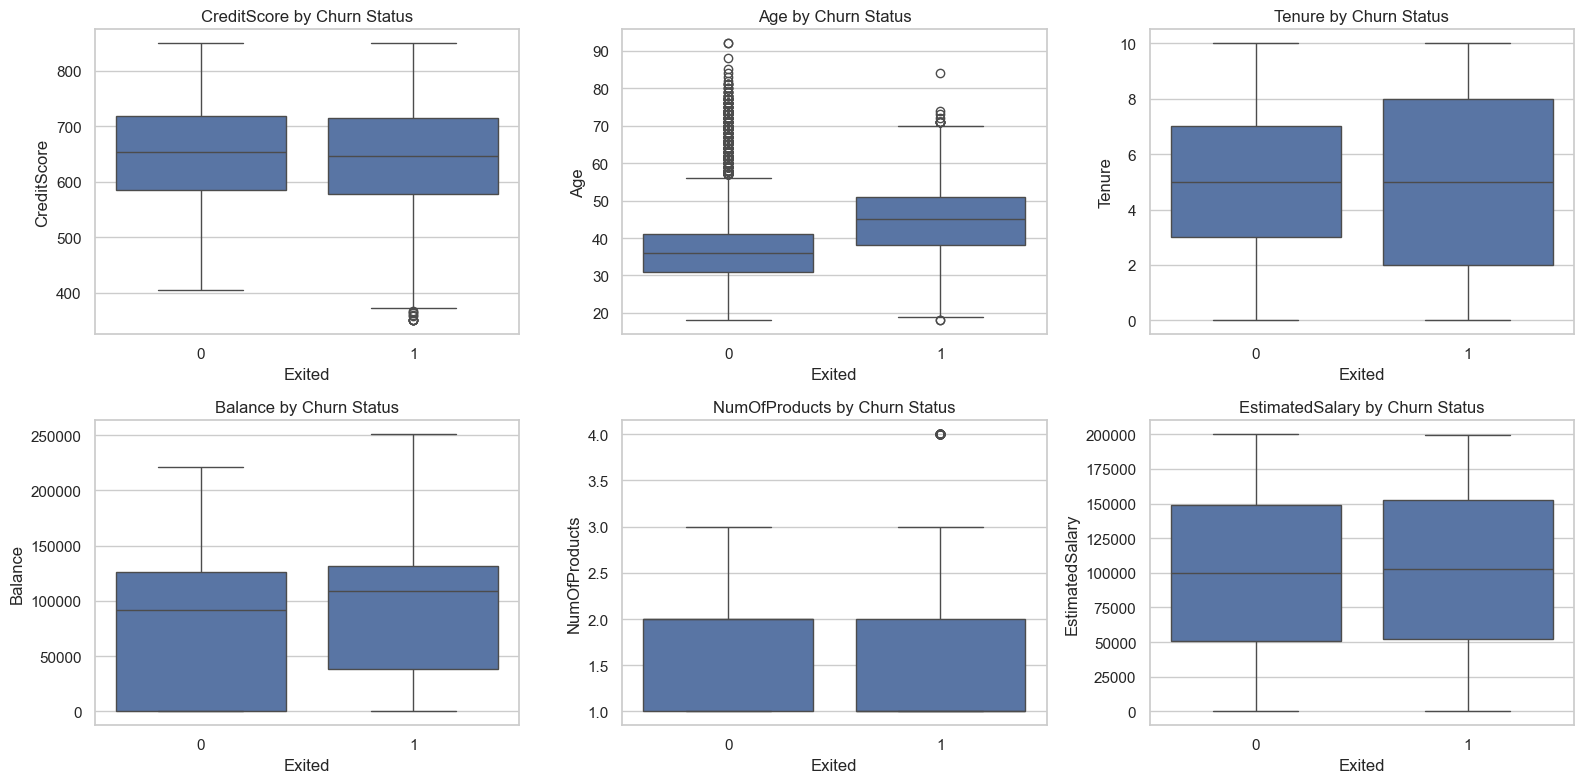

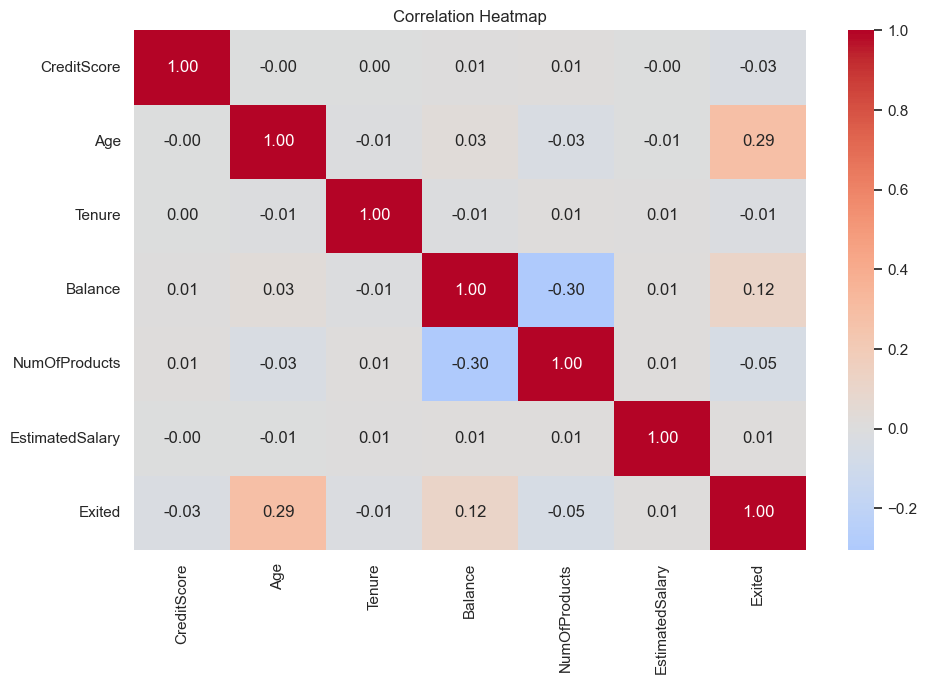

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for axis, feature in zip(axes.ravel(), numeric_features):
    sns.boxplot(data=cleaned_df, x=target_column, y=feature, ax=axis)
    axis.set_title(f"{feature} by Churn Status")
    axis.set_xlabel("Exited")
    axis.set_ylabel(feature)
plt.tight_layout()

plt.figure(figsize=(10, 7))
correlation_matrix = cleaned_df[numeric_features + [target_column]].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()


The numerical plots make it easier to compare churned and retained customers. Age, balance,
and product ownership often show more useful separation than credit score alone. Correlation
should be treated as an exploratory signal, not proof of a causal relationship.


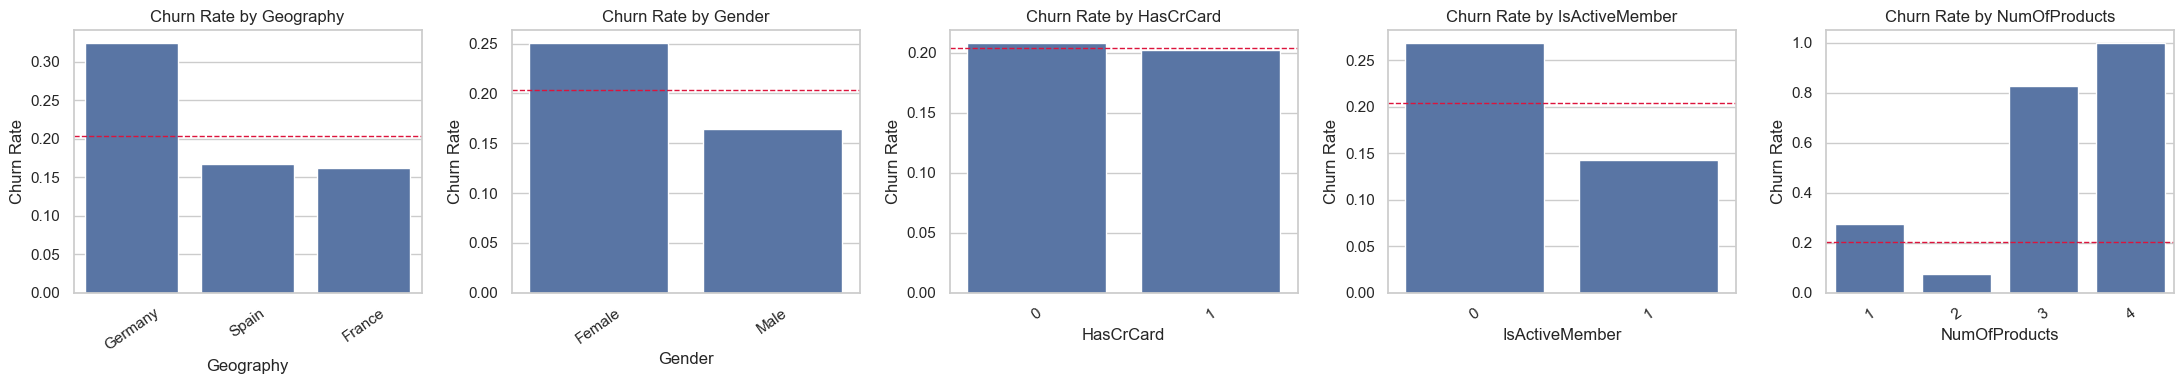

In [9]:
categorical_features = [
    "Geography",
    "Gender",
    "HasCrCard",
    "IsActiveMember",
    "NumOfProducts",
]

fig, axes = plt.subplots(1, len(categorical_features), figsize=(22, 4))
for axis, feature in zip(axes, categorical_features):
    churn_by_feature = (
        cleaned_df.groupby(feature, observed=False)[target_column]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )
    sns.barplot(data=churn_by_feature, x=feature, y=target_column, ax=axis)
    axis.axhline(churn_rate, color="crimson", linestyle="--", linewidth=1)
    axis.set_title(f"Churn Rate by {feature}")
    axis.set_xlabel(feature)
    axis.set_ylabel("Churn Rate")
    axis.tick_params(axis="x", rotation=35)
plt.tight_layout()


In [10]:
segment_summary = (
    cleaned_df.groupby(["Geography", "Gender"], observed=False)[target_column]
    .agg(churn_rate="mean", customers="size")
    .sort_values("churn_rate", ascending=False)
)

display(segment_summary.style.format({"churn_rate": "{:.1%}"}))


**Final EDA insights:** churn varies across geography, gender, activity status, and product
ownership. Inactive customers and selected customer segments deserve particular attention.
These observations guide feature engineering and business discussion, while the model will
quantify their combined predictive value.


## 6. Feature Engineering

The existing ratio features are retained and calculated safely. A small number of additional
features capture product engagement and life-stage patterns without adding artificial or
difficult-to-explain variables.

- `BalanceSalaryRatio`: account balance relative to estimated salary.
- `TenureByAge`: tenure adjusted for customer age.
- `CreditScoreGivenAge`: credit score in the context of age.
- `ProductsPerTenure`: product usage relative to customer tenure.
- `ActivityScore`: simple interaction between activity status and products held.
- `AgeGroup`: interpretable customer life-stage category.


In [11]:
def create_features(dataframe):
    '''Create business-focused features without modifying the input dataframe.'''
    feature_df = dataframe.copy()
    salary = feature_df["EstimatedSalary"].clip(lower=1)
    age = feature_df["Age"].clip(lower=1)

    feature_df["BalanceSalaryRatio"] = feature_df["Balance"] / salary
    feature_df["TenureByAge"] = feature_df["Tenure"] / age
    feature_df["CreditScoreGivenAge"] = feature_df["CreditScore"] / age
    feature_df["ProductsPerTenure"] = feature_df["NumOfProducts"] / (feature_df["Tenure"] + 1)
    feature_df["ActivityScore"] = feature_df["IsActiveMember"] * feature_df["NumOfProducts"]
    feature_df["AgeGroup"] = pd.cut(
        feature_df["Age"],
        bins=[0, 30, 40, 50, 60, np.inf],
        labels=["Under 30", "30-39", "40-49", "50-59", "60+"],
    ).astype(str)
    return feature_df


model_df = create_features(cleaned_df)
model_df.head()


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,TenureByAge,CreditScoreGivenAge,ProductsPerTenure,ActivityScore,AgeGroup
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.000000,0.047619,14.738095,0.333333,1,40-49
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.744677,0.024390,14.829268,0.500000,1,40-49
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1.401375,0.190476,11.952381,0.333333,0,40-49
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.000000,0.025641,17.923077,1.000000,0,30-39
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1.587055,0.046512,19.767442,0.333333,1,40-49


## 7. Data Preparation

The target is separated before modeling, then the data is split using stratification so the
churn rate is similar in training and test sets. Numerical variables are median-imputed and
standardized; categorical variables are mode-imputed and one-hot encoded inside a pipeline.


In [12]:
X = model_df.drop(columns=target_column)
y = model_df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

numeric_model_features = X.select_dtypes(include="number").columns.tolist()
categorical_model_features = X.select_dtypes(exclude="number").columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_model_features),
        ("categorical", categorical_transformer, categorical_model_features),
    ]
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Training churn rate: {y_train.mean():.1%}")
print(f"Test churn rate: {y_test.mean():.1%}")


Training set: (8000, 16)
Test set: (2000, 16)
Training churn rate: 20.4%
Test churn rate: 20.3%


## 8. Model Training

We begin with four complementary classifiers. Logistic regression provides an interpretable
linear baseline, a decision tree captures simple non-linear rules, random forest reduces the
variance of individual trees, and SVM can learn more complex decision boundaries.


In [13]:
def build_pipeline(model):
    '''Attach shared preprocessing to a classifier.'''
    return Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])


model_pipelines = {
    "Logistic Regression": build_pipeline(
        LogisticRegression(max_iter=1_000, random_state=RANDOM_STATE)
    ),
    "Decision Tree": build_pipeline(
        DecisionTreeClassifier(random_state=RANDOM_STATE)
    ),
    "Random Forest": build_pipeline(
        RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
    ),
    "Support Vector Machine": build_pipeline(
        SVC(probability=True, random_state=RANDOM_STATE)
    ),
}

try:
    from xgboost import XGBClassifier

    model_pipelines["XGBoost"] = build_pipeline(
        XGBClassifier(
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    )
    print("XGBoost is available and will be included in the comparison.")
except ImportError:
    print("XGBoost is not installed; continuing with the scikit-learn models.")

for model_name, pipeline in model_pipelines.items():
    pipeline.fit(X_train, y_train)
    print(f"Trained: {model_name}")


XGBoost is available and will be included in the comparison.
Trained: Logistic Regression
Trained: Decision Tree
Trained: Random Forest
Trained: Support Vector Machine
Trained: XGBoost


## 9. Hyperparameter Tuning

Random forest is tuned with stratified five-fold cross-validation. The search space focuses on
parameters that have the greatest impact on model complexity and generalization. Accuracy is
used as the tuning metric to match the primary project objective, while the full metric set is
reviewed during evaluation.


In [14]:
random_forest_parameters = {
    "model__n_estimators": [200, 300, 500, 700],
    "model__max_depth": [None, 6, 10, 14],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", 0.5, 0.8],
    "model__class_weight": [None, "balanced"],
}

random_forest_search = RandomizedSearchCV(
    estimator=build_pipeline(
        RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)
    ),
    param_distributions=random_forest_parameters,
    n_iter=20,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    refit=True,
)
random_forest_search.fit(X_train, y_train)

tuned_random_forest = random_forest_search.best_estimator_
model_pipelines["Tuned Random Forest"] = tuned_random_forest

print(f"Best CV accuracy: {random_forest_search.best_score_:.3f}")
print("Best parameters:")
print(random_forest_search.best_params_)


Best CV accuracy: 0.862
Best parameters:
{'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': 0.8, 'model__max_depth': 10, 'model__class_weight': None}


## 10. Model Evaluation

Each model is evaluated on the same untouched test set. In addition to accuracy, the notebook
reports precision, recall, F1 score, and ROC-AUC so that performance on churners is not hidden
by the larger retained-customer class.



Logistic Regression
-------------------
              precision    recall  f1-score   support

           0       0.84      0.97      0.90      1593
           1       0.70      0.28      0.40       407

    accuracy                           0.83      2000
   macro avg       0.77      0.63      0.65      2000
weighted avg       0.81      0.83      0.80      2000


Decision Tree
-------------
              precision    recall  f1-score   support

           0       0.88      0.87      0.87      1593
           1       0.50      0.53      0.51       407

    accuracy                           0.80      2000
   macro avg       0.69      0.70      0.69      2000
weighted avg       0.80      0.80      0.80      2000


Random Forest
-------------
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.77      0.45      0.57       407

    accuracy                           0.86      2000
   macro avg       0.82      

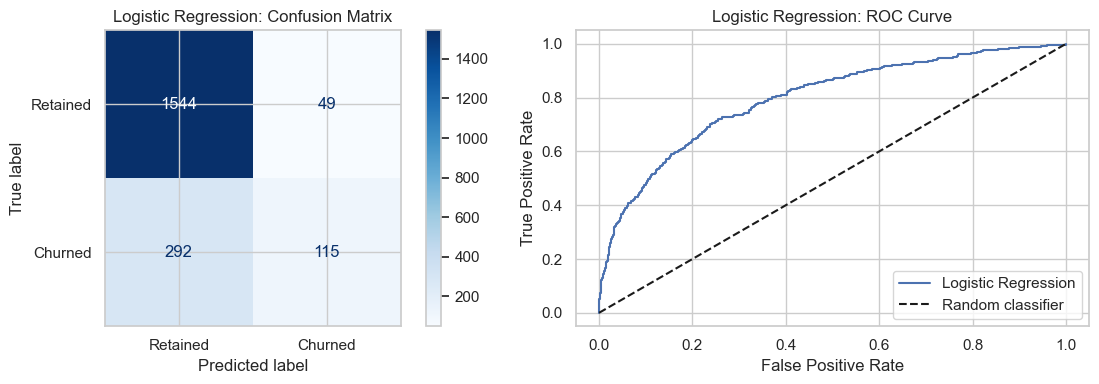

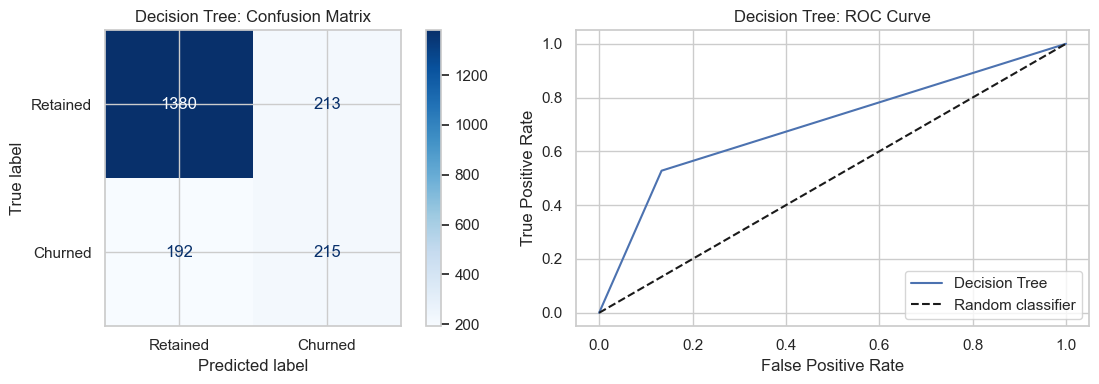

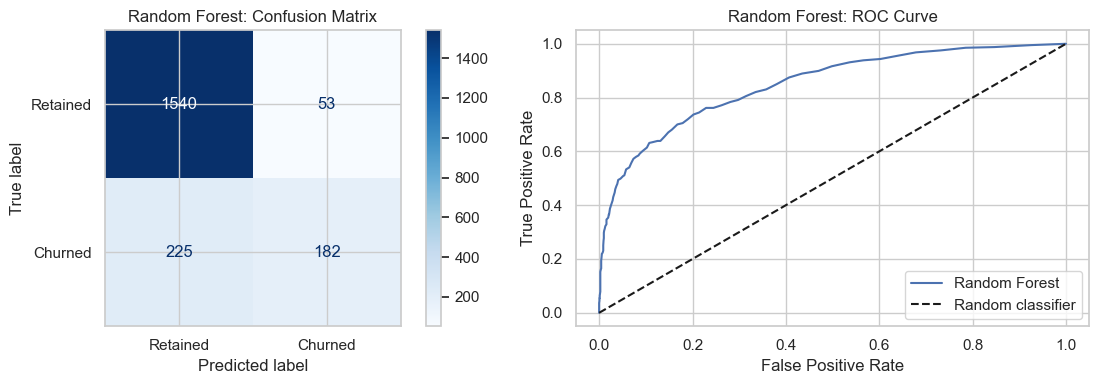

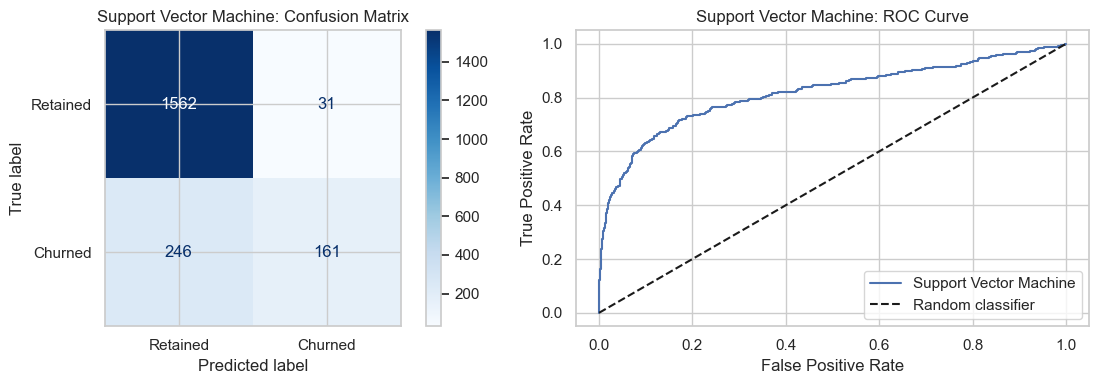

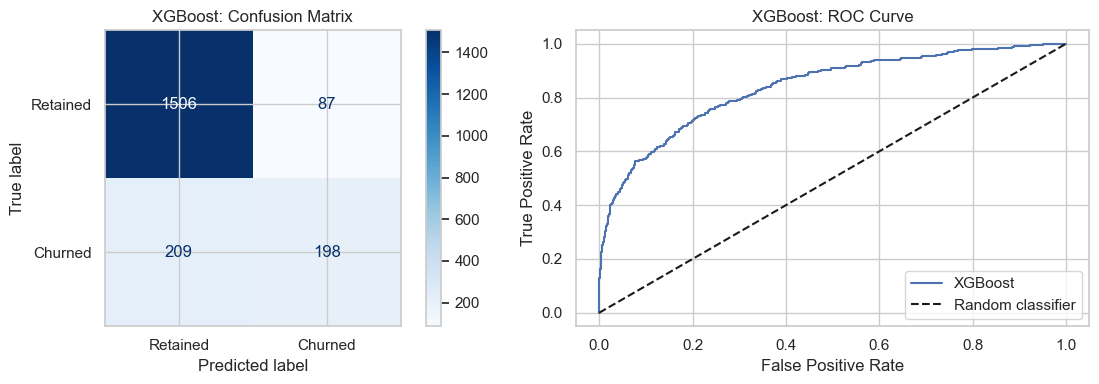

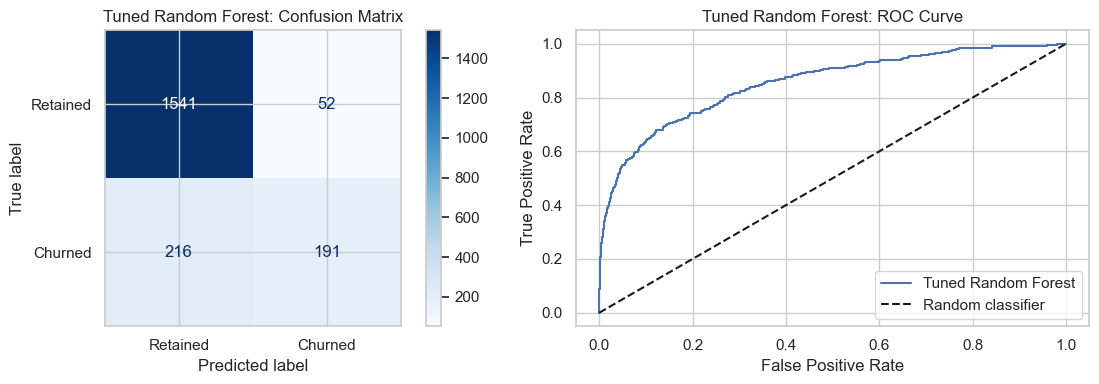

In [15]:
def evaluate_model(model_name, pipeline, features, labels):
    '''Return classification metrics and show confusion matrix and ROC curve.'''
    predictions = pipeline.predict(features)
    probabilities = pipeline.predict_proba(features)[:, 1]

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(labels, predictions),
        "Precision": precision_score(labels, predictions, zero_division=0),
        "Recall": recall_score(labels, predictions, zero_division=0),
        "F1 Score": f1_score(labels, predictions, zero_division=0),
        "ROC AUC": roc_auc_score(labels, probabilities),
    }

    print(f"\n{model_name}")
    print("-" * len(model_name))
    print(classification_report(labels, predictions, zero_division=0))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ConfusionMatrixDisplay.from_predictions(
        labels,
        predictions,
        display_labels=["Retained", "Churned"],
        cmap="Blues",
        ax=axes[0],
    )
    axes[0].set_title(f"{model_name}: Confusion Matrix")

    false_positive_rate, true_positive_rate, _ = roc_curve(labels, probabilities)
    axes[1].plot(false_positive_rate, true_positive_rate, label=model_name)
    axes[1].plot([0, 1], [0, 1], "k--", label="Random classifier")
    axes[1].set_title(f"{model_name}: ROC Curve")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].legend(loc="lower right")
    plt.tight_layout()

    return metrics


evaluation_results = []
for model_name, pipeline in model_pipelines.items():
    evaluation_results.append(evaluate_model(model_name, pipeline, X_test, y_test))


## 11. Model Comparison

This table compares all trained models using the holdout test set. The best model should be
selected by considering the business cost of missed churners versus unnecessary outreach, not
only by its accuracy.


In [16]:
comparison_df = (
    pd.DataFrame(evaluation_results)
    .sort_values(["ROC AUC", "F1 Score"], ascending=False)
    .reset_index(drop=True)
)

display(comparison_df.style.format({
    "Accuracy": "{:.3f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1 Score": "{:.3f}",
    "ROC AUC": "{:.3f}",
}))

best_model_name = comparison_df.loc[0, "Model"]
print(f"Best model by ROC-AUC: {best_model_name}")


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Tuned Random Forest,0.866,0.786,0.469,0.588,0.854
1,Random Forest,0.861,0.774,0.447,0.567,0.849
2,XGBoost,0.852,0.695,0.486,0.572,0.839
3,Support Vector Machine,0.862,0.839,0.396,0.538,0.818
4,Logistic Regression,0.830,0.701,0.283,0.403,0.796
5,Decision Tree,0.797,0.502,0.528,0.515,0.697


Best model by ROC-AUC: Tuned Random Forest


## 12. Business Insights

The model identifies customers at risk; EDA explains where retention teams may start. These
segment-level findings should be combined with operational context before launching a campaign
or treating a model correlation as a causal conclusion.


In [17]:
business_segments = {
    "Geography": cleaned_df.groupby("Geography")[target_column].mean(),
    "Gender": cleaned_df.groupby("Gender")[target_column].mean(),
    "Activity Status": cleaned_df.groupby("IsActiveMember")[target_column].mean(),
    "Products": cleaned_df.groupby("NumOfProducts")[target_column].mean(),
}

for segment_name, churn_rates in business_segments.items():
    print(f"\nChurn rate by {segment_name}:")
    display(churn_rates.sort_values(ascending=False).to_frame("churn_rate").style.format("{:.1%}"))



Churn rate by Geography:


,churn_rate
Geography,
Germany,32.4%
Spain,16.7%
France,16.2%



Churn rate by Gender:


,churn_rate
Gender,
Female,25.1%
Male,16.5%



Churn rate by Activity Status:


,churn_rate
IsActiveMember,
0,26.9%
1,14.3%



Churn rate by Products:


,churn_rate
NumOfProducts,
4,100.0%
3,82.7%
1,27.7%
2,7.6%


Key takeaways for a retention team:

- Prioritize high-risk customers identified by the best-performing model.
- Review inactive customer journeys, because activity status is a useful churn signal.
- Tailor campaigns by customer segment rather than using one blanket retention offer.
- Monitor precision and recall after deployment, since customer behaviour and churn rates can change.


## 13. Conclusion

This notebook follows a reproducible churn-modeling workflow and compares several classifiers
using an untouched test set. The selected model can support retention prioritization, but it
should be retrained periodically and assessed against the bank's real cost of churn and
customer-contact capacity.
